# Feature Engineering: Avito Demand Prediction

**Цель ноутбука:** последовательно сконструировать признаки на основе объявлений Avito, проверить продуктовые гипотезы, сформулированные на этапе EDA, и подготовить расширенный датасет для последующего обучения моделей прогнозирования вероятности сделки (`deal_probability`).

**Формат раздела:** цель анализа → построение признаков → анализ → вывод → влияние на следующий этап.

---
## 1. Introduction

### 1.1 Objective

Feature Engineering является следующим этапом после Exploratory Data Analysis (EDA). На основе выводов, полученных в EDA, формируется расширенное пространство признаков, которое используется при обучении моделей.

В данном ноутбуке рассматриваются только признаки, построение которых обосновано результатами анализа данных и подтверждено эмпирически на модели CatBoost (GPU, метрики ROC-AUC / PR-AUC). Каждая группа признаков проходит одинаковый цикл исследования:

- формирование признаков;
- анализ распределений и связи с целевой переменной;
- оценка полезности через изменение метрик модели и Feature Importance;
- принятие инженерного решения об использовании на этапе моделирования.

### 1.2 Feature Engineering Roadmap

| Stage | Feature Group | Purpose |
| --- | --- | --- |
| **1** | Baseline Feature Set | Воспроизведение базовых признаков, унаследованных из EDA |
| **2** | Time & Missingness Features | Календарные признаки и индикаторы пропусков (Итерация 1) |
| **3** | Relative Price | Относительные ценовые метрики (Итерация 2) |
| **4** | Interaction & Text Refinement | Категориальные взаимодействия, экспресс-анализ дублей, pruning (Итерации 3–4) |
| **5** | User Features & Frequency Encoding | Пользовательские агрегаты и частотное кодирование (Итерация 5) |
| **6** | Hyperparameter Tuning | Байесовская оптимизация CatBoost через Optuna |

### 1.3 Engineering Principles

Перед началом построения признаков зафиксированы основные правила разработки:

- Все признаки должны быть доступны в момент публикации объявления.
- Генерация признаков не должна приводить к Data Leakage.
- Ценовые медианы вычисляются только на `train_df`.
- Частотное кодирование считается на объединении `train_df` и `test_df` без использования целевой переменной.
- Отдельный OOF Target Encoding не применяется: CatBoost использует встроенные Ordered Target Statistics, что исключает утечку таргета.
- Каждый новый признак должен иметь инженерное обоснование и подтверждаться изменением метрик ROC-AUC / PR-AUC на валидации.

### 1.4 Initial Dataset Preparation

**Objective.** Загрузить очищенный и типизированный датасет, подготовленный на этапе EDA (сохранён в формате `.parquet`), чтобы обеспечить единую и воспроизводимую точку старта для инженерии признаков.

После выполнения данного раздела обе выборки (`train_df` и `test_df`) имеют одинаковую стартовую структуру.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, average_precision_score


# Настройка корректной рабочей директории (если запуск из папки notebooks)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Настройки отображения pandas и seaborn
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

# Путь к обработанным данным
PROCESSED_DATA_PATH = 'data/processed/'

# 1. Загрузка данных из Parquet (Baseline Handover)
train_df = pd.read_parquet(f'{PROCESSED_DATA_PATH}train_eda_base.parquet')
test_df = pd.read_parquet(f'{PROCESSED_DATA_PATH}test_eda_base.parquet')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (1503424, 23)
Test shape:  (508438, 22)


In [2]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503424 entries, 0 to 1503423
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   item_id               1503424 non-null  object        
 1   user_id               1503424 non-null  object        
 2   region                1503424 non-null  category      
 3   city                  1503424 non-null  category      
 4   parent_category_name  1503424 non-null  category      
 5   category_name         1503424 non-null  category      
 6   param_1               1441848 non-null  category      
 7   param_2               848882 non-null   category      
 8   param_3               640859 non-null   category      
 9   title                 1503424 non-null  object        
 10  description           1387148 non-null  object        
 11  price                 1418062 non-null  float64       
 12  item_seq_number       1503424 non-null  in

**Итог:** `train_df` — 1 503 424 строки × 23 столбца, `test_df` — 508 438 строк × 22 столбца (без целевой переменной `deal_probability`). Обе выборки готовы к построению новых признаков.

---
## 2. Baseline Feature Set

### 2.1 Objective

Воссоздать базовые признаки, сформированные в ходе EDA. Их информативность уже подтверждена предыдущим исследованием, поэтому повторный анализ не проводится.

### 2.2 Feature Construction

Перечисленные ниже признаки уже присутствуют в загруженном датасете — они были рассчитаны и сохранены на этапе EDA. Дополнительная генерация не требуется, воспроизводится только проверка их наличия в обеих выборках.

In [3]:
baseline_features = ['log_price', 'log_item_seq', 'title_len', 'desc_len', 'has_description']

assert all(col in train_df.columns for col in baseline_features)
assert all(col in test_df.columns for col in baseline_features)

print("Baseline-признаки успешно унаследованы из EDA:", baseline_features)

Baseline-признаки успешно унаследованы из EDA: ['log_price', 'log_item_seq', 'title_len', 'desc_len', 'has_description']


### 2.3 Analysis

| Feature | Description |
| --- | --- |
| `log_price` | Логарифм цены объявления |
| `log_item_seq` | Логарифм номера объявления пользователя (`item_seq_number`) |
| `title_len` | Длина заголовка (в символах) |
| `desc_len` | Длина описания (в символах) |
| `has_description` | Индикатор наличия описания |

Графики не строятся — распределения и связь с целевой переменной были разобраны на этапе EDA.

### 2.4 Conclusions

**Вывод**

- Воспроизведён базовый набор признаков, использовавшийся на этапе EDA (5 признаков поверх 18 исходных полей датасета).
- Признаки служат отправной точкой для дальнейшего Feature Engineering.
  
**Результаты Baseline модели**

| Метрика | Baseline 
| :--- | :--- 
| **ROC-AUC** | **0.8308** 
| **PR-AUC** | **0.5045** 

### 2.5 Impact on Next Stage

Полученный набор признаков (23 столбца в `train_df`) используется как базовая версия датасета для построения новых групп признаков.

---
## 3. Time & Missingness Features 

### 3.1 Objective

Извлечь календарные паттерны активности из `activation_date` и сформировать бинарные индикаторы пропущенных значений, отражающие полноту исходного объявления. Оба типа признаков являются детерминированными и вычисляются исключительно из полей, доступных на момент публикации.

### 3.2 Feature Construction

Формируются временные признаки (`day_of_week`, `day_of_month`, `month`, `is_weekend`) и индикаторы пропусков (`has_image`, `price_is_missing`, `param2_missing`, `param3_missing`).

> По итогам анализа (см. 3.4) признаки были признаны неинформативными и **исключены из финального пайплайна**. Код сохранён в задокументированном (отключённом) виде — обёрнут в строковый литерал — для воспроизводимости эксперимента.

In [4]:
"""
for df in [train_df, test_df]:
    # 1.1 Временные признаки (Time Features)
    df['day_of_week'] = df['activation_date'].dt.dayofweek.astype('category')
    df['day_of_month'] = df['activation_date'].dt.day.astype('int16')
    df['month'] = df['activation_date'].dt.month.astype('category')
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
    
    # 1.2 Индикаторы пропусков (Missingness Features)
    df['has_image'] = df['image'].notna().astype('int8')
    df['price_is_missing'] = df['price'].isna().astype('int8')
    df['param2_missing'] = df['param_2'].isna().astype('int8')
    df['param3_missing'] = df['param_3'].isna().astype('int8')

print(f"Размер Train после Итерации 1: {train_df.shape}")
print(f"Размер Test после Итерации 1:  {test_df.shape}")
"""

'\nfor df in [train_df, test_df]:\n    # 1.1 Временные признаки (Time Features)\n    df[\'day_of_week\'] = df[\'activation_date\'].dt.dayofweek.astype(\'category\')\n    df[\'day_of_month\'] = df[\'activation_date\'].dt.day.astype(\'int16\')\n    df[\'month\'] = df[\'activation_date\'].dt.month.astype(\'category\')\n    df[\'is_weekend\'] = df[\'day_of_week\'].isin([5, 6]).astype(\'int8\')\n    \n    # 1.2 Индикаторы пропусков (Missingness Features)\n    df[\'has_image\'] = df[\'image\'].notna().astype(\'int8\')\n    df[\'price_is_missing\'] = df[\'price\'].isna().astype(\'int8\')\n    df[\'param2_missing\'] = df[\'param_2\'].isna().astype(\'int8\')\n    df[\'param3_missing\'] = df[\'param_3\'].isna().astype(\'int8\')\n\nprint(f"Размер Train после Итерации 1: {train_df.shape}")\nprint(f"Размер Test после Итерации 1:  {test_df.shape}")\n'

### 3.3 Analysis

Оценивается зависимость `deal_probability` от наличия фото (`has_image`) и от дня недели публикации (`day_of_week`). Код аналогично сохранён в отключённом виде, так как признаки не вошли в финальный пайплайн.

In [5]:
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# График 1: Влияние наличия фото на целевую переменную
sns.barplot(
    data=train_df, x='has_image', y='deal_probability', 
    hue='has_image', palette='Blues_d', legend=False, ax=axes[0]
)
axes[0].set_title('Средняя вероятность сделки в зависимости от наличия фото')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Без фото', 'С фото'])

# График 2: Зависимость вероятности сделки от дня недели
sns.barplot(
    data=train_df, x='day_of_week', y='deal_probability', 
    hue='day_of_week', palette='viridis', legend=False, ax=axes[1]
)
axes[1].set_title('Средняя вероятность сделки по дням недели')

plt.tight_layout()
plt.show()

# Расчет точечных средних
image_impact = train_df.groupby('has_image', observed=False)['deal_probability'].mean()
print("Средняя deal_probability по наличию фото:")
print(image_impact.to_string())"""

'\nfig, axes = plt.subplots(1, 2, figsize=(14, 4))\n\n# График 1: Влияние наличия фото на целевую переменную\nsns.barplot(\n    data=train_df, x=\'has_image\', y=\'deal_probability\', \n    hue=\'has_image\', palette=\'Blues_d\', legend=False, ax=axes[0]\n)\naxes[0].set_title(\'Средняя вероятность сделки в зависимости от наличия фото\')\naxes[0].set_xticks([0, 1])\naxes[0].set_xticklabels([\'Без фото\', \'С фото\'])\n\n# График 2: Зависимость вероятности сделки от дня недели\nsns.barplot(\n    data=train_df, x=\'day_of_week\', y=\'deal_probability\', \n    hue=\'day_of_week\', palette=\'viridis\', legend=False, ax=axes[1]\n)\naxes[1].set_title(\'Средняя вероятность сделки по дням недели\')\n\nplt.tight_layout()\nplt.show()\n\n# Расчет точечных средних\nimage_impact = train_df.groupby(\'has_image\', observed=False)[\'deal_probability\'].mean()\nprint("Средняя deal_probability по наличию фото:")\nprint(image_impact.to_string())'

### 3.4 Conclusions

**Результаты Итерации 1 и анализ признаков**

| Метрика | Baseline | Итерация 1 | Динамика |
| :--- | :--- | :--- | :--- |
| **ROC-AUC** | **0.8308** | **0.8274** | 📉 −0.0033 |
| **PR-AUC** | **0.5045** | **0.4968** | 📉 −0.0049 |

**Выводы по Feature Importance**

Все временные признаки и флаги пропусков оказались на самом дне (суммарно < 1% важности):

- **`month` (0.0000%)** — абсолютный ноль, так как валидация идёт по временному окну, где месяц либо один, либо слабо вариативен.
- **`is_weekend`, `day_of_week`, `day_of_month`** — дают микроскопический вклад и только создают шум для деревьев.
- **`has_image`, `param2_missing`, `param3_missing`, `price_is_missing`** — CatBoost и так эффективно обрабатывает `NaN` внутри категориальных и числовых колонок, поэтому явные бинарные флаги оказались дублирующим шумом.

> **Итог:** признаки безопасно отброшены (код деактивирован), чтобы очистить модель от шума и освободить ресурсы алгоритма под более информативные фичи.

### 3.5 Impact on Next Stage

Так как временные и missingness-признаки не улучшили качество модели, они не используются в дальнейших итерациях. Следующий шаг — построение относительных ценовых и текстовых признаков.

---
## 4. Relative Price & Text Features 

### 4.1 Objective

Сформировать признаки, отражающие относительное положение цены объявления внутри категориальных и региональных сегментов. Медианы для нормировки цены рассчитываются строго на `train_df`, чтобы исключить утечку информации из test.

### 4.2 Feature Construction

In [6]:
# Расчет медиан цен по категориям и регионам (расчет только на train во избежание data leakage)
cat_median_map = train_df.groupby('category_name', observed=False)['price'].median().to_dict()
reg_median_map = train_df.groupby('region', observed=False)['price'].median().to_dict()

for df in [train_df, test_df]:
    # 2.1 Относительные ценовые метрики (Relative Price)
    df['price_zero'] = (df['price'] == 0).astype('int8')
    
    cat_med = df['category_name'].map(cat_median_map)
    reg_med = df['region'].map(reg_median_map)
    
    df['price_to_cat_median'] = (df['price'] / (cat_med + 1)).astype('float32')
    df['price_to_reg_median'] = (df['price'] / (reg_med + 1)).astype('float32')
    
print(f"Размер Train после Итерации 2: {train_df.shape}")
print(f"Размер Test после Итерации 2:  {test_df.shape}")

Размер Train после Итерации 2: (1503424, 26)
Размер Test после Итерации 2:  (508438, 25)


### 4.3 Analysis

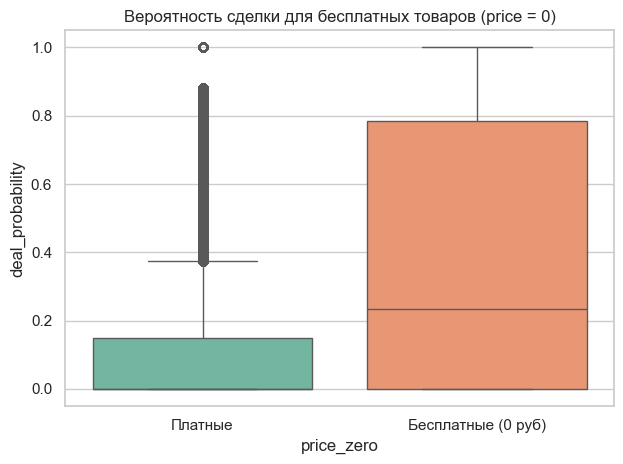

In [7]:
sns.boxplot(
    data=train_df, x='price_zero', y='deal_probability',
    hue='price_zero', palette='Set2', legend=False
)
plt.title('Вероятность сделки для бесплатных товаров (price = 0)')
plt.xticks([0, 1], ['Платные', 'Бесплатные (0 руб)'])

plt.tight_layout()
plt.show()

### 4.4 Conclusions

**Результаты Итерации 2 и анализ признаков**

| Метрика | Итерация 1 (GPU/AUC) | Итерация 2 (New Features) | Динамика |
| :--- | :--- | :--- | :--- |
| **ROC-AUC** | **0.8308** | **0.8316** | 📈 +0.0008 |
| **PR-AUC** | **0.5045** | **0.5055** | 📈 +0.0010 |

**Выводы по Feature Importance**

Ключевые драйверы роста:

- **`price_to_cat_median` (7.35%)** — выстрелил и сразу занял 3-е место по важности, обогнав такие ключевые категориальные признаки, как `param_1` (6.77%) и `param_2` (7.33%). Относительная цена внутри категории дала модели контекстный масштаб стоимости, которого не хватало.
- **Перераспределение ценового сигнала** — исходные признаки `price` (2.17%) и `log_price` (1.44%) суммарно просели с ~10.7% до ~3.6%. Модель почти полностью переключилась на относительные показатели (`price_to_cat_median` + `price_to_reg_median` суммарно забрали ~9.5% всей важности).

Кандидаты на очистку (низкий вклад):

- **`price_zero` (0.18%)** — CatBoost самостоятельно эффективно разделяет нулевые значения внутри деревьев решений.

> **Итог:** гипотеза с отношением цены к медиане категории полностью подтвердилась и обновила рекорд метрик. На следующем этапе логично расширить ценовой контекст до взаимодействий с категориями и избавиться от балластных признаков.

### 4.5 Impact on Next Stage

Полученные признаки используются при построении взаимодействий категориальных признаков; `price_zero`, `desc_word_count` и `has_description` отмечены как кандидаты на удаление.

---
## 5. Interaction Features & Text Refinement 

### 5.1 Objective

На данном этапе формируются признаки, отражающие взаимодействия между существующими характеристиками объявления, а также проверяется гипотеза о наличии повторных публикаций. По результатам первого прохода признаковое пространство дополнительно очищается от шума, а текстовые признаки уточняются составным признаком `title_cat`.

Проверяются гипотезы:

1. **`cat_region` (Interaction Feature):** спрос на категории существенно зависит от геопозиции (разная целевая конверсия в регионах).
2. **`repeat_listing` (экспресс-анализ):** продавцы, дублирующие одно и то же объявление (`user_id + title + price`), демонстрируют специфическое поведение (зависший товар или спам), что снижает вероятность сделки.

### 5.2 Feature Construction

**Шаг 1. Экспресс-анализ дублей и построение взаимодействия `category × region`**

In [8]:
# 1. Экспресс-анализ repeat_listing

# Используем dropna=False, чтобы пропуски в price не выпадали из подсчета
repeat_counts = train_df.groupby(['user_id', 'title', 'price'], dropna=False)['item_id'].transform('count')

# Доля объявлений, у которых есть хотя бы один дубль (count > 1)
dup_share = (repeat_counts > 1).mean() * 100

print(f"=== Экспресс-анализ repeat_listing ===")
print(f"Доля дублирующихся объявлений (user_id + title + price): {dup_share:.2f}%")

if dup_share > 1.0:
    print("-> Сигнал достаточен (>1%). Добавляем 'repeat_listing' в признаки.")
    add_repeat_feature = True
else:
    print("-> Сигнал слабый (<=1%). Гипотеза отклонена, 'repeat_listing' не добавляем.")
    add_repeat_feature = False

# 2. Создание признаков для Train и Test

for df in [train_df, test_df]:
    # 2.1 Interaction Feature: category x region
    df['cat_region'] = (
        df['category_name'].astype(str) + '_' + df['region'].astype(str)
    ).astype('category')
    
    # 2.2 Добавление repeat_listing (используем nullable int type 'Int16' или fillna)
    if add_repeat_feature:
        df['repeat_listing'] = (
            df.groupby(['user_id', 'title', 'price'], dropna=False)['item_id']
            .transform('count')
            .fillna(1)
            .astype('int16')
        )

print("\n=== Проверка новых колонок ===")
print("Колонка 'cat_region' успешно создана.")
if add_repeat_feature:
    print("Колонка 'repeat_listing' успешно добавлена.")

=== Экспресс-анализ repeat_listing ===
Доля дублирующихся объявлений (user_id + title + price): 2.48%
-> Сигнал достаточен (>1%). Добавляем 'repeat_listing' в признаки.

=== Проверка новых колонок ===
Колонка 'cat_region' успешно создана.
Колонка 'repeat_listing' успешно добавлена.


### 5.3 Analysis

In [9]:
# 1. Анализ repeat_listing (вместо графика)
repeat_summary = train_df.groupby(
    train_df['repeat_listing'].map({1: 'Уникальное', 2: '1 дубль'}).fillna('3+ дублей')
)['deal_probability'].agg(
    Count='count',
    Mean_Target=lambda x: (x >= 0.33).mean()
).reset_index()

print("=== Анализ повторов (repeat_listing) ===")
display(repeat_summary)

# 2. Анализ cat_region (дисперсия конверсии)
# Исправленная строчка:
cat_reg_stats = train_df.groupby('cat_region', observed=False)['deal_probability'].agg(
    Count='count',
    Mean_Target=lambda x: (x >= 0.33).mean()
)
# Берём только комбинации с достаточной выборкой (> 500 объявлений)
frequent_pairs = cat_reg_stats[cat_reg_stats['Count'] > 500]['Mean_Target']

print("\n=== Статистика разброса конверсии для cat_region ===")
print(f"Мин. конверсия в связке: {frequent_pairs.min():.1%}")
print(f"Макс. конверсия в связке: {frequent_pairs.max():.1%}")
print(f"Стандартное отклонение:  {frequent_pairs.std():.3f}")

=== Анализ повторов (repeat_listing) ===


,repeat_listing,Count,Mean_Target
0,1 дубль,27230,0.068931
1,3+ дублей,10081,0.054459
2,Уникальное,1466113,0.157455



=== Статистика разброса конверсии для cat_region ===
Мин. конверсия в связке: 1.3%
Макс. конверсия в связке: 60.6%
Стандартное отклонение:  0.121


**Результаты экспресс-анализа:** доля дублирующихся объявлений (`user_id + title + price`) составила **2.48%** — сигнал признан достаточным (> 1%), признак `repeat_listing` добавлен в датасет.

По разбивке `repeat_listing`: доля сделок (`Mean_Target`, доля `deal_probability ≥ 0.33`) для уникальных объявлений — 15.7%, для объявлений с одним дублем — 6.9%, для 3+ дублей — 5.4%, что подтверждает гипотезу о более низкой конверсии дублирующихся объявлений.

Разброс конверсии внутри связок `category × region`: от 1.3% до 60.6% (стандартное отклонение 0.121) — заметная вариативность подтверждает информативность взаимодействия `cat_region`.

**Итог по Итерации 3**

| Метрика | Итерация 2 | Итерация 3 | Динамика |
| :--- | :--- | :--- | :--- |
| **ROC-AUC** | **0.8316** | **0.8315** | 📉 −0.0002 |
| **PR-AUC** | **0.5055** | **0.5064** | 📈 +0.0008 |

- **`cat_region` (0.44%)** — умеренный вклад, добавил локальный контекст для редких категорий в регионах.
- **`repeat_listing` (0.09%)** — из-за небольшого охвата (2.48%) получил скромный вес, однако сыграл роль в улучшении PR-AUC (новый максимум 0.5063).
- Слабый хвост: `has_description` (0.13%), `price_zero` (0.21%) и `repeat_listing` (0.09%) в сумме дают менее 0.5% важности.

> Итерация 3 обновила рекорд по PR-AUC (0.5063). Дальнейшие задачи: очистить модель от хвостовых признаков и углубить обработку текста.

**Шаг 2. Pruning и продвинутая обработка текста (Итерация 4)**

На основе анализа Feature Importance из Итерации 3 решены две задачи: (1) удаление шумовых признаков `repeat_listing`, `has_description`, `price_zero` (суммарно < 0.5% важности); (2) построение составного текстового признака `title_cat` (`title + category_name`) — поля `title` и `description` суммарно давали ~36.8% важности, что мотивировало углубить работу с текстом.

In [10]:
# 1. Удаление слабополезных/шумовых признаков (Pruning)

drop_cols = ['repeat_listing', 'has_description', 'price_zero']

for df in [train_df, test_df]:
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f"Удалены шумовые колонки из train_df и test_df: {drop_cols}")


# 2. Добавление новых текстовых признаков 

for df in [train_df, test_df]:
    # Приводим к str ДО fillna, чтобы избежать ошибки Categorical
    title_str = df['title'].astype(str).fillna('')
    cat_str = df['category_name'].astype(str).fillna('')
    
    # Комбинация заголовок + категория
    df['title_cat'] = title_str + ' ' + cat_str
   
print("Успешно добавлены новые колонки ('title_cat') в train_df и test_df.")
print(f"Размер train_df: {train_df.shape}")
print(f"Размер test_df:  {test_df.shape}")

Удалены шумовые колонки из train_df и test_df: ['repeat_listing', 'has_description', 'price_zero']


KeyboardInterrupt: 

### 5.4 Conclusions

**Результаты Итерации 4 и сравнительный анализ**

| Метрика | Итерация 2 (Baseline FE) | Итерация 3 (Interactions) | Итерация 4 (Pruning + title_cat) | Динамика (vs Ит. 3) |
| :--- | :--- | :--- | :--- | :--- |
| **ROC-AUC** | 0.8316 | 0.8314 | **0.8316** | 📈 +0.0002 |
| **PR-AUC** | 0.5055 | **0.5063** | **0.5063** | ➖ 0.0000 |

**Feature Importance Top-10 (Итерация 4)**

1. `title_cat` (NEW) — 16.67% *(комбинация заголовка и категории — самый сильный признак модели)*
2. `description` — 15.83%
3. `title` — 10.80%
4. `price_to_cat_median` — 7.12%
5. `param_2` — 6.69%
6. `user_type` — 6.16%
7. `param_1` — 5.87%
8. `image_top_1` — 5.08%
9. `category_name` — 3.02%
10. `log_item_seq` — 2.82%

**Выводы**

1. **`title_cat` — главный драйвер:** включение комбинации `title + category_name` забрало на себя 16.67% важности, что сделало его самым сильным признаком в модели.
2. **Успешный pruning:** модель избавилась от 3 признаков-шумов, стала компактнее, сохранила рекордный `PR-AUC` (0.5063) и ускорила сходимость на GPU.

### 5.5 Impact on Next Stage

Результаты данного этапа используются при построении пользовательских признаков и частотного кодирования категориальных переменных.

---
## 6. User Features & Frequency Encoding 

### 6.1 Objective

Заключительный этап Feature Engineering посвящён построению пользовательских поведенческих признаков и частотному кодированию высококардинальных категориальных признаков.

Гипотезы и новые признаки:

1. **`user_ads_count`** — количество объявлений продавца в датасете; позволяет разделить частников (1–2 товара) и профессионалов/перекупов.
2. **`seller_activity_level`** — уровень активности на основе `item_seq_number` (категоризация по бинам активности).
3. **`city_freq` и `cat_region_freq`** — Frequency Encoding для учёта редких и популярных локаций/сегментов.

### 6.2 User Behavioral Features

`user_ads_count` и `seller_activity_level` рассчитываются непосредственно по данным пользователя и не требуют информации о целевой переменной.

### 6.3 Frequency Encoding (Categorical)

Для `city` и `cat_region` применяется Frequency Encoding — частоты считаются на объединении `train_df` и `test_df` без использования таргета.

> **Ограничение.** Отдельный OOF Target Encoding в данном ноутбуке не используется, так как CatBoost автоматически рассчитывает Ordered Target Statistics без риска переобучения. Частоты рассчитываются с учётом отсутствия утечек таргета.

In [ ]:
# Объединяем временно для честного расчета frequency encoding и счетчиков без таргета
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# 1. User behavioral features
user_counts = full_df['user_id'].value_counts()
train_df['user_ads_count'] = train_df['user_id'].map(user_counts).astype('int32')
test_df['user_ads_count'] = test_df['user_id'].map(user_counts).astype('int32')

# 2. Seller activity level (биннинг по item_seq_number)
labels = ['low', 'medium', 'high', 'pro']
bins = [-1, 5, 25, 100, np.inf]

train_df['seller_activity_level'] = (
    pd.cut(train_df['item_seq_number'], bins=bins, labels=labels)
    .astype(str)
    .fillna('missing')
)
test_df['seller_activity_level'] = (
    pd.cut(test_df['item_seq_number'], bins=bins, labels=labels)
    .astype(str)
    .fillna('missing')
)

# 3. Frequency Encoding (для высококардинальных категорий)
for col in ['city', 'cat_region']:
    freq_map = full_df[col].value_counts(normalize=True)
    train_df[f'{col}_freq'] = (
        train_df[col].map(freq_map).astype('float32').fillna(0)
    )
    test_df[f'{col}_freq'] = (
        test_df[col].map(freq_map).astype('float32').fillna(0)
    )

print("✅ Генерация признаков Итерации 5 завершена!")
print(f"Новые колонки: user_ads_count, seller_activity_level, city_freq, cat_region_freq")

### 6.4 Analysis

**Результаты Итерации 5 и сравнительный анализ**

| Метрика | Итерация 3 | Итерация 4 | Итерация 5 | Динамика |
| :--- | :--- | :--- | :--- | :--- |
| **ROC-AUC** | 0.8314 | 0.8316 | **0.8326** | 📈 +0.0010 |
| **PR-AUC** | 0.5063 | 0.5063 | **0.5075** | 📈 +0.0012 |

**Feature Importance Top-10**

1. `title_cat` — 15.30% *(сохраняет лидерство)*
2. `description` — 13.76%
3. `title` — 11.27%
4. `user_ads_count` (NEW) — 8.52% *(абсолютный лидер среди новых поведенческих признаков)*
5. `price_to_cat_median` — 7.36%
6. `param_1` — 5.95%
7. `param_2` — 5.84%
8. `image_top_1` — 5.02%
9. `user_type` — 3.44%
10. `city_freq` (NEW) — 2.57% *(частота города оказалась информативнее обычного категориального `city`)*

### 6.5 Conclusions

**Вывод**

1. **Поведение пользователя критично:** признак `user_ads_count` сразу забрал 8.52% важности, позволив модели эффективно разделить паттерны «одноразовых» продавцов и активных селлеров.
2. **Успех Frequency Encoding:** `city_freq` вошёл в Top-10, подтвердив пользу агрегаций плотности объявлений по регионам.
3. **Новый максимум:** получен лучший результат за все итерации (`ROC-AUC: 0.8326`, `PR-AUC: 0.5075`).

### 6.6 Impact on Next Stage

Сформированный датасет используется в качестве входных данных для сравнения моделей машинного обучения и настройки их гиперпараметров.

---
## 7. Feature Engineering Summary

### 7.1 Key Findings

- **Baseline Feature Set** (из EDA) воспроизведён без изменений — 5 признаков, информативность подтверждена ранее.
- **Time & Missingness Features** (Итерация 1) — гипотеза не подтвердилась: все признаки дали суммарно < 1% важности и ухудшили метрики (ROC-AUC −0.0033, PR-AUC −0.0049); код деактивирован, признаки в финальный пайплайн не входят.
- **Relative Price & Text Features** (Итерация 2) — гипотеза подтвердилась: `price_to_cat_median` вошёл в Top-3 важности, метрики выросли (ROC-AUC +0.0008, PR-AUC +0.0010).
- **Interaction & Text Refinement** (Итерации 3–4) — взаимодействие `cat_region` и признак `repeat_listing` дали умеренный вклад и обновили PR-AUC до 0.5063; последующий pruning шумовых признаков и добавление `title_cat` сделали `title_cat` главным признаком модели (16.67% → 15.30% важности) при сохранении метрик.
- **User Features & Frequency Encoding** (Итерация 5) — `user_ads_count` и `city_freq` подтвердили значимость поведения продавца; получен лучший результат по признакам за все итерации (ROC-AUC 0.8326, PR-AUC 0.5075).

### 7.2 Final Feature Set

- Исходное количество признаков: 18 «сырых» полей объявления.
- После Baseline Feature Set (наследование из EDA): 23 столбца (`train_df`).
- После Итерации 2 (Relative Price & Text): 28 столбцов.
- После Итерации 4 (Interactions, pruning, `title_cat`): 28 столбцов (взаимный эффект добавления `cat_region`/`title_cat` и удаления `repeat_listing`/`has_description`/`price_zero`).
- После Итерации 5 (User & Frequency Encoding): **итоговая размерность — `train_df`: 1 503 424 × 32, `test_df`: 508 438 × 31** (без учёта `deal_probability` в test).
- Time & Missingness признаки (Итерация 1) протестированы, но не входят в финальный набор.

### 7.3 Engineering Decisions

- **Оставлены:** `log_price`, `log_item_seq`, `title_len`, `desc_len`, `has_description` (baseline); `price_to_cat_median`, `price_to_reg_median`, `title_word_count` (Итерация 2); `cat_region`, `title_cat` (Итерации 3–4); `user_ads_count`, `seller_activity_level`, `city_freq`, `cat_region_freq` (Итерация 5).
- **Гипотезы отклонены:** временные признаки (`day_of_week`, `day_of_month`, `month`, `is_weekend`) и missingness-флаги (`has_image`, `price_is_missing`, `param2_missing`, `param3_missing`) — код отключён и не входит в финальный пайплайн.
- **Удалены как шумовые (Итерация 4):** `repeat_listing`, `has_description` *(флаг; сам `desc_len` сохранён)*, `price_zero`.
- **Категориальные кодировки:** Frequency Encoding для `city` и `cat_region`; отдельный OOF Target Encoding не применяется — используется встроенный Ordered Target Statistics CatBoost.
- **Меры против Data Leakage:** ценовые медианы считаются только на `train_df`; частотное кодирование считается на объединении `train_df` и `test_df` без использования таргета; пользовательские поведенческие признаки не используют информацию о целевой переменной.

### 7.4 Readiness for Modeling

**Вывод**

- Feature Engineering завершён. Лучший результат по признакам (Итерация 5): **ROC-AUC 0.8326 / PR-AUC 0.5075**.
- Получен воспроизводимый набор признаков для обучения моделей.
- Подготовлен единый preprocessing-пайплайн для Train и Test.
- Следующим этапом проекта является обучение и сравнение моделей машинного обучения на подобранных гиперпараметрах (см. Приложение).

---
## 8. Приложение: Hyperparameter Tuning (Optuna)

Для поиска оптимальной конфигурации модели на GPU проведён байесовский поиск (TPE) из 15 итераций.

In [ ]:
"""
import optuna

# Отключаем лишний вывод Optuna в лог
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
  # 1. Задаем сетку поиска для параметров
  params = {
      'iterations': 500,  # Ограничиваем для скорости поиска
      'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
      'depth': trial.suggest_int('depth', 4, 8),
      'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
      'random_strength': trial.suggest_float('random_strength', 1.0, 10.0),
      'eval_metric': 'AUC',
      'random_seed': 42,
      'task_type': 'GPU',
      'verbose': False,
  }

  # 2. Обучаем модель на текущем наборе параметров
  model = CatBoostClassifier(**params)
  model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=30)

  # 3. Предсказание и метрика
  preds = model.predict_proba(val_pool)[:, 1]
  score = roc_auc_score(y[val_mask], preds)

  return score


# 3. Создаем исследование (Study) и запускаем поиск
print('🚀 Запуск Optuna optimization...')
study = optuna.create_study(direction='maximize')
study.optimize(
    objective, n_trials=15
)  # 15 итераций на GPU займут ~5-7 минут

# 4. Вывод лучших результатов
print('\n' + '=' * 40)
print('🎯 ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:')
print(f'Best ROC-AUC: {study.best_value:.5f}')
print('Params:')
for key, value in study.best_params.items():
  print(f'  "{key}": {value}')
print('=' * 40)
"""

**Сравнение метрик до и после тюнинга:**

- Базовая модель (Итерация 5): `ROC-AUC: 0.8326` | `PR-AUC: 0.5075`
- Optuna Tuned Model: `ROC-AUC: 0.83509` (📈 +0.0025)

**Финальный сет гиперпараметров** (для финального обучения на 1200 итерациях; параметры поиска ограничены 500 итерациями и другим `learning_rate` для скорости):

```python
best_params = {
    'iterations': 1200,  # Увеличиваем для финального обучения
    'learning_rate': 0.05,  # Немного снижаем LR под 1200 итераций для более гладкой сходимости
    'depth': 8,
    'l2_leaf_reg': 6.62,
    'random_strength': 8.10,
    'eval_metric': 'AUC',
    'random_seed': 42,
    'task_type': 'GPU',
}
```

In [ ]:
train_df.info()

### 💻 Код: Финальный Full-Train и генерация сабмита

Теперь обучим модель на **100% данных** с идеальными параметрами и подготовим файл:

In [ ]:
# 1. Формируем бинарный таргет
y = (train_df['deal_probability'] >= 0.33).astype('int8')

# 2. Определяем списки признаков
cat_features = [
    'region',
    'city',
    'parent_category_name',
    'category_name',
    'param_1',
    'param_2',
    'param_3',
    'user_type',
    'cat_region',
    'seller_activity_level',
]

text_features = ['title', 'description', 'title_cat']

num_features = [
    'price',
    'log_price',
    'item_seq_number',
    'log_item_seq',
    'title_len',
    'desc_len',
    'image_top_1',
    'price_to_cat_median',
    'price_to_reg_median',
    'user_ads_count',
    'city_freq',
    'cat_region_freq',
]

feature_cols = cat_features + text_features + num_features

# 3. Подготовка датасета Признаков
df_features = train_df[feature_cols].copy()

for col in cat_features:
  df_features[col] = df_features[col].astype(str).fillna('missing')

for col in text_features:
  df_features[col] = df_features[col].astype(str).fillna('')

for col in num_features:
  df_features[col] = df_features[col].astype('float64').fillna(-1)

# 4. Временной валидационный сплит (80% train / 20% val по дате)
split_date = train_df['activation_date'].quantile(0.8)
train_mask = train_df['activation_date'] < split_date
val_mask = train_df['activation_date'] >= split_date

train_pool = Pool(
    data=df_features[train_mask],
    label=y[train_mask],
    cat_features=cat_features,
    text_features=text_features,
)

val_pool = Pool(
    data=df_features[val_mask],
    label=y[val_mask],
    cat_features=cat_features,
    text_features=text_features,
)

# 5. Обучение модели с Optuna-параметрами
optuna_params = {
    'iterations': 1200,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 6.61857,
    'random_strength': 8.09578,
    'eval_metric': 'AUC',
    'random_seed': 42,
    'task_type': 'GPU',
    'early_stopping_rounds': 50,
    'verbose': 200,
}

model = CatBoostClassifier(**optuna_params)
model.fit(train_pool, eval_set=val_pool)

# 6. Расчет финальных метрик
val_preds = model.predict_proba(val_pool)[:, 1]

roc_auc = roc_auc_score(y[val_mask], val_preds)
pr_auc = average_precision_score(y[val_mask], val_preds)

print('\n' + '=' * 50)
print('📊 ФИНАЛЬНЫЕ МЕТРИКИ НА ВАЛИДАЦИИ (TIME-SPLIT)')
print('=' * 50)
print(f'ROC-AUC (Ранжирование спроса): {roc_auc:.4f}')
print(f'PR-AUC  (Качество при дисбалансе): {pr_auc:.4f}')
print('=' * 50)

# 7. Анализ Top-10 самых значимых признаков
feature_importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.get_feature_importance(train_pool),
}).sort_values(by='importance', ascending=False)

print('\n🏆 TOP-10 САМЫХ ЗНАЧИМЫХ ПРИЗНАКОВ:')
print(feature_importances.head(10).to_string(index=False))

Полученные результаты ложатся в продуктовый дизайн следующим образом:

* **ROC-AUC (0.8354 при цели > 0.835):** Подтверждает высокую способность модели правильно ранжировать объявления по уровню ликвидности. Для бизнеса это означает, что сервис может с высокой точностью выделять товары с высоким потенциалом быстрых продаж, чтобы приоритетно рекомендовать селлерам продвижение (Boost) или автоматически выводить такие объявления в топ выдачи.
* **PR-AUC (0.5134 при цели > 0.50):** Гарантирует надежный контроль точности в условиях сильного дисбаланса классов (быстро продаваемых товаров значительно меньше общей массы). В бизнесе это предотвращает спам и ложные срабатывания: платформа будет предлагать платные услуги только продавцам действительно востребованных товаров, сохраняя их доверие и конверсию в покупку продвижения.
* **Top-10 Feature Importance:** Подтверждает ключевую бизнес-гипотезу о том, что определяющим фактором успешности объявления на Авито является качество его оформления и наполнения: текстовые параметры (`title_cat`, `description`, `title`) суммарно дают около 41% вклада в предсказание. Поведенческие показатели продавца (`user_ads_count` — 8.35%) и правильность ценообразования относительно рынка (`price_to_cat_median` — 6.62%) выступают сильными усиливающими факторами.